In [4]:
#bibliotecas
import pandas as pd
import numpy as np
from sklearn import tree as tr
from sklearn import linear_model as lm
from sklearn import ensemble as en
from sklearn import preprocessing as pp
from sklearn import metrics as mt
from matplotlib import pyplot as plt

In [5]:
#Separação entre treino/ validação / teste

X_train = pd.read_csv('dataset1/X_training (1).csv')
y_train = pd.read_csv('dataset1/y_training (1).csv')
X_test = pd.read_csv('dataset1/X_test (1).csv')
y_test = pd.read_csv('dataset1/y_test (1).csv')
X_validation = pd.read_csv('dataset1/X_validation (1).csv')
y_validation = pd.read_csv('dataset1/y_val.csv')

## 1. Decision Tree Regreession

In [6]:
tree_reg = tr.DecisionTreeRegressor()
tree_reg.fit(X_train,y_train)

yhat_val =tree_reg.predict(X_train)

In [7]:
#Ensaio sobre os dados de treinamento

r2_value = mt.r2_score(y_train, yhat_val)
mse_value = mt.mean_squared_error(y_train,yhat_val)
rmse_value = np.sqrt(mse_value)
mae_value = mt.mean_absolute_error(y_train,yhat_val)
mape_value = mt.mean_absolute_percentage_error(y_train,yhat_val)

print(f"R2 : {r2_value} ")
print(f"MSE : {mse_value} ")
print(f"RMSE : {rmse_value} ")
print(f"MAE : {mae_value} ")
print(f"MAPE : {mape_value} ")

R2 : 0.9917566957405923 
MSE : 3.940402971731975 
RMSE : 1.9850448286454327 
MAE : 0.21409852496986279 
MAPE : 0.08262787375974134 


In [8]:
values = [i for i in range(1,60)]
values_rmse = list()

for i in values:
    tree_reg = tr.DecisionTreeRegressor(max_depth=i)
    tree_reg.fit(X_train, y_train)
    
    yhat_val = tree_reg.predict(X_validation)
    mse = mt.mean_squared_error(y_validation, yhat_val)
    
    values_rmse.append(np.sqrt(mse))

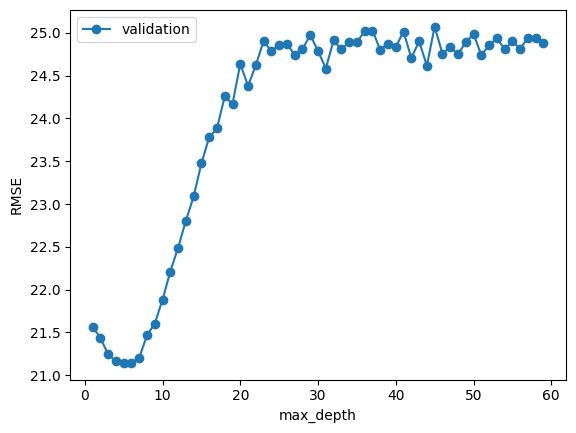

In [9]:
plt.plot(values, values_rmse, '-o', label = 'validation')
plt.xlabel('max_depth')
plt.ylabel('RMSE')
plt.legend()
plt.show()

In [10]:
#melhor max_depth = 4 (mais simples )
tree_reg = tr.DecisionTreeRegressor(max_depth=4)
tree_reg.fit(X_train, y_train)

yhat_val = tree_reg.predict(X_validation)

In [11]:
#Ensaio sobre os dados de validação

r2_value = mt.r2_score(y_validation, yhat_val)
mse_value = mt.mean_squared_error(y_validation,yhat_val)
rmse_value = np.sqrt(mse_value)
mae_value = mt.mean_absolute_error(y_validation,yhat_val)
mape_value = mt.mean_absolute_percentage_error(y_validation,yhat_val)

print(f"R2 : {r2_value} ")
print(f"MSE : {mse_value} ")
print(f"RMSE : {rmse_value} ")
print(f"MAE : {mae_value} ")
print(f"MAPE : {mape_value} ")

R2 : 0.06216761663185333 
MSE : 447.8258531271403 
RMSE : 21.16189625546681 
MAE : 16.849288338389197 
MAPE : 8.536141474557683 


In [12]:
#Junção dos dados de treinamento com os de validação

tree_reg_last = tr.DecisionTreeRegressor(max_depth= 4)
tree_reg_last.fit( np.concatenate( (X_train, X_validation) ), 
                   np.concatenate((y_train, y_validation)) 
)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_le

In [13]:
#Ensaio sobre os dados de teste
yhat_val = tree_reg_last.predict(X_test.values)

r2_value = mt.r2_score(y_test, yhat_val)
mse_value = mt.mean_squared_error(y_test,yhat_val)
rmse_value = np.sqrt(mse_value)
mae_value = mt.mean_absolute_error(y_test,yhat_val)
mape_value = mt.mean_absolute_percentage_error(y_test,yhat_val)

print(f"R2 : {r2_value} ")
print(f"MSE : {mse_value} ")
print(f"RMSE : {rmse_value} ")
print(f"MAE : {mae_value} ")
print(f"MAPE : {mape_value} ")

R2 : 0.06504830500131586 
MSE : 455.2288927021588 
RMSE : 21.336093660793647 
MAE : 17.033428968872123 
MAPE : 8.129477577701318 


## 2. Regression Polinomial

In [14]:
poly = pp.PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train) 

model = lm.LinearRegression()
model.fit(X_train_poly,y_train)

#Predict
yhat_val = model.predict(X_train_poly)

In [15]:
# Ensaio sobre os dados de treinamento
r2_value = mt.r2_score(y_train, yhat_val)
mse_value = mt.mean_squared_error(y_train,yhat_val)
rmse_value = np.sqrt(mse_value)
mae_value = mt.mean_absolute_error(y_train,yhat_val)
mape_value = mt.mean_absolute_percentage_error(y_train,yhat_val)

print(f"R2 : {r2_value} ")
print(f"MSE : {mse_value} ")
print(f"RMSE : {rmse_value} ")
print(f"MAE : {mae_value} ")
print(f"MAPE : {mape_value} ")

R2 : 0.09419491057528084 
MSE : 432.9862096386579 
RMSE : 20.80832068280999 
MAE : 16.458031755824436 
MAPE : 8.350539820928141 


In [16]:
values_degree = [i for i in range(1,5)]
values_rmse  = list()
values_mae = list()
values_mape = list()

for i in values_degree: 
    poly = pp.PolynomialFeatures(degree=i, include_bias=False)
    X_train_poly = poly.fit_transform(X_train)
    X_validation_poly = poly.transform(X_validation)
    
    model = lm.LinearRegression()
    model.fit(X_train_poly, y_train)
    
    #Predict nos dados de validação
    yhat_val = model.predict(X_validation_poly)
    
    mse = mt.mean_squared_error(y_validation,yhat_val)
    
    values_rmse.append(np.sqrt(mse))
    values_mae.append(mt.mean_absolute_error(y_validation,yhat_val))
    values_mape.append(mt.mean_absolute_percentage_error(y_validation,yhat_val))

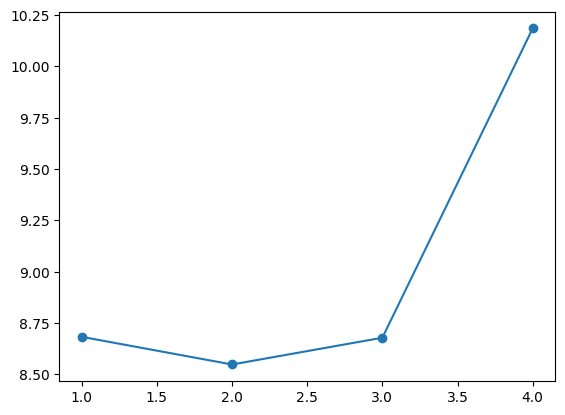

In [17]:
plt.plot(values_degree, values_mape, '-o', label='validation')

In [18]:
poly = pp.PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_validation_poly = poly.fit_transform(X_validation)


model = lm.LinearRegression()
model.fit(X_train_poly,y_train)

yhat_val = model.predict(X_validation_poly)

In [19]:
#Ensaio sobre os dados de validação

r2_value = mt.r2_score(y_validation, yhat_val)
mse_value = mt.mean_squared_error(y_validation,yhat_val)
rmse_value = np.sqrt(mse_value)
mae_value = mt.mean_absolute_error(y_validation,yhat_val)
mape_value = mt.mean_absolute_percentage_error(y_validation,yhat_val)

print(f"R2 : {r2_value} ")
print(f"MSE : {mse_value} ")
print(f"RMSE : {rmse_value} ")
print(f"MAE : {mae_value} ")
print(f"MAPE : {mape_value} ")

R2 : 0.06647668389711614 
MSE : 445.76822347127563 
RMSE : 21.113223900467585 
MAE : 16.749939090484027 
MAPE : 8.547931034605396 


In [20]:
#Junção dados de treinamento + validação
poly_final = pp.PolynomialFeatures(degree=2, include_bias=False)

X_train_validation = np.concatenate([X_train,X_validation])
y_train_validation = np.concatenate([y_train,y_validation])

X_train_validation_poly = poly_final.fit_transform(X_train_validation)

model_last = lm.LinearRegression()
model_last.fit(X_train_validation_poly,y_train_validation)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [21]:
#Ensaio sobre os dados de teste
X_test_poly = poly.transform(X_test)

yhat_val = model_last.predict(X_test_poly)

r2_value = mt.r2_score(y_test, yhat_val)
mse_value = mt.mean_squared_error(y_test,yhat_val)
rmse_value = np.sqrt(mse_value)
mae_value = mt.mean_absolute_error(y_test,yhat_val)
mape_value = mt.mean_absolute_percentage_error(y_test,yhat_val)

print(f"R2 : {r2_value} ")
print(f"MSE : {mse_value} ")
print(f"RMSE : {rmse_value} ")
print(f"MAE : {mae_value} ")
print(f"MAPE : {mape_value} ")

R2 : 0.0909005985060245 
MSE : 442.64138576579643 
RMSE : 21.039044316836172 
MAE : 16.736414061349997 
MAPE : 8.27697168501549 


## 3. Linear Regression

In [22]:
model = lm.LinearRegression()
model.fit(X_train, y_train)

#Predict nos dados de treinamento
yhat_train = model.predict(X_train)

In [23]:
#Ensaio sobre os dados de treinamento

r2_value = mt.r2_score(y_train, yhat_train)
mse_value = mt.mean_squared_error(y_train,yhat_train)
rmse_value = np.sqrt(mse_value)
mae_value = mt.mean_absolute_error(y_train,yhat_train)
mape_value = mt.mean_absolute_percentage_error(y_train,yhat_train)

print(f"R2 : {r2_value} ")
print(f"MSE : {mse_value} ")
print(f"RMSE : {rmse_value} ")
print(f"MAE : {mae_value} ")
print(f"MAPE : {mape_value} ")

R2 : 0.04605830473391903 
MSE : 455.99611182562677 
RMSE : 21.35406546364478 
MAE : 16.998249066011095 
MAPE : 8.653185943804512 


In [24]:
#Predict nos dados de validação
yhat_val = model.predict(X_validation)

In [25]:
#Ensaio sobre os dados de validação

r2_value = mt.r2_score(y_validation, yhat_val)
mse_value = mt.mean_squared_error(y_validation,yhat_val)
rmse_value = np.sqrt(mse_value)
mae_value = mt.mean_absolute_error(y_validation,yhat_val)
mape_value = mt.mean_absolute_percentage_error(y_validation,yhat_val)

print(f"R2 : {r2_value} ")
print(f"MSE : {mse_value} ")
print(f"RMSE : {rmse_value} ")
print(f"MAE : {mae_value} ")
print(f"MAPE : {mape_value} ")

R2 : 0.0399248303815406 
MSE : 458.44704184393123 
RMSE : 21.41137645841414 
MAE : 17.039753759960327 
MAPE : 8.682541883735295 


In [26]:
#Junção dos dados de treinamento com os de validação
model_last = lm.LinearRegression()
model_last.fit(np.concatenate([X_train, X_validation]), np.concatenate([y_train, y_validation]))

#Predict nos dados de teste
yhat_test = model_last.predict(X_test)

c:\Users\oheit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


In [27]:
#Ensaio sobre os dados de teste

r2_value = mt.r2_score(y_test, yhat_test)
mse_value = mt.mean_squared_error(y_test,yhat_test)
rmse_value = np.sqrt(mse_value)
mae_value = mt.mean_absolute_error(y_test,yhat_test)
mape_value = mt.mean_absolute_percentage_error(y_test,yhat_test)

print(f"R2 : {r2_value} ")
print(f"MSE : {mse_value} ")
print(f"RMSE : {rmse_value} ")
print(f"MAE : {mae_value} ")
print(f"MAPE : {mape_value} ")

R2 : 0.05116551777115064 
MSE : 461.9884353525593 
RMSE : 21.4939162404751 
MAE : 17.144197086987703 
MAPE : 8.531355027820084 


## 4. Random Forest Regressor

In [28]:
rf_reg = en.RandomForestRegressor(n_estimators=100, random_state=0)
rf_reg.fit(X_train, np.ravel(y_train))

yhat_train = rf_reg.predict(X_train)

In [29]:
#Ensaio sobre os dados de treinamento

r2_value = mt.r2_score(y_train, yhat_train)
mse_value = mt.mean_squared_error(y_train,yhat_train)
rmse_value = np.sqrt(mse_value)
mae_value = mt.mean_absolute_error(y_train,yhat_train)
mape_value = mt.mean_absolute_percentage_error(y_train,yhat_train)

print(f"R2 : {r2_value} ")
print(f"MSE : {mse_value} ")
print(f"RMSE : {rmse_value} ")
print(f"MAE : {mae_value} ")
print(f"MAPE : {mape_value} ")

R2 : 0.9028168842467658 
MSE : 46.45474994801846 
RMSE : 6.815772146134175 
MAE : 4.860772578122971 
MAPE : 2.5779585497476467 


In [30]:
#Busca de hiperparâmetro (n_estimators) usando os dados de validação
values_n_estimators = [10, 25, 50, 75, 100, 150, 200]
values_rmse = list()

for i in values_n_estimators:
    rf_reg = en.RandomForestRegressor(n_estimators=i, random_state=0)
    rf_reg.fit(X_train, np.ravel(y_train))

    yhat_val = rf_reg.predict(X_validation)
    mse = mt.mean_squared_error(y_validation, yhat_val)

    values_rmse.append(np.sqrt(mse))

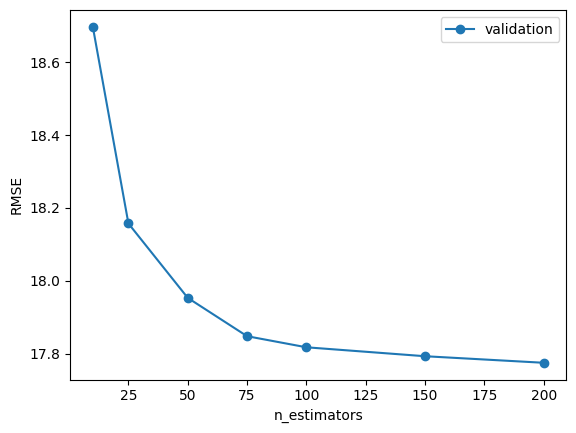

In [31]:
plt.plot(values_n_estimators, values_rmse, '-o', label='validation')
plt.xlabel('n_estimators')
plt.ylabel('RMSE')
plt.legend()
plt.show()

In [32]:
rf_reg = en.RandomForestRegressor(n_estimators=100, random_state=0)
rf_reg.fit(X_train, np.ravel(y_train))

yhat_val = rf_reg.predict(X_validation)

In [33]:
#Ensaio sobre os dados de validação

r2_value = mt.r2_score(y_validation, yhat_val)
mse_value = mt.mean_squared_error(y_validation,yhat_val)
rmse_value = np.sqrt(mse_value)
mae_value = mt.mean_absolute_error(y_validation,yhat_val)
mape_value = mt.mean_absolute_percentage_error(y_validation,yhat_val)

print(f"R2 : {r2_value} ")
print(f"MSE : {mse_value} ")
print(f"RMSE : {rmse_value} ")
print(f"MAE : {mae_value} ")
print(f"MAPE : {mape_value} ")

R2 : 0.33514028344793256 
MSE : 317.47823497572665 
RMSE : 17.817918929429627 
MAE : 13.002222942656154 
MAPE : 7.030919696789032 


In [34]:
#Junção dos dados de treinamento com os de validação
rf_reg_last = en.RandomForestRegressor(n_estimators=100, random_state=0)
rf_reg_last.fit(np.concatenate([X_train, X_validation]), np.ravel(np.concatenate([y_train, y_validation])))

yhat_test = rf_reg_last.predict(X_test)

c:\Users\oheit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


In [35]:
#Ensaio sobre os dados de teste

r2_value = mt.r2_score(y_test, yhat_test)
mse_value = mt.mean_squared_error(y_test,yhat_test)
rmse_value = np.sqrt(mse_value)
mae_value = mt.mean_absolute_error(y_test,yhat_test)
mape_value = mt.mean_absolute_percentage_error(y_test,yhat_test)

print(f"R2 : {r2_value} ")
print(f"MSE : {mse_value} ")
print(f"RMSE : {rmse_value} ")
print(f"MAE : {mae_value} ")
print(f"MAPE : {mape_value} ")

R2 : 0.4039838206275421 
MSE : 290.20085938095133 
RMSE : 17.03528277960044 
MAE : 12.227423196880546 
MAPE : 6.33835047271183 


## 5. Linear Regression Lasso

In [36]:
model = lm.Lasso(alpha=1)
model.fit(X_train, y_train)

yhat_train = model.predict(X_train)

In [37]:
#Ensaio sobre os dados de treinamento

r2_value = mt.r2_score(y_train, yhat_train)
mse_value = mt.mean_squared_error(y_train,yhat_train)
rmse_value = np.sqrt(mse_value)
mae_value = mt.mean_absolute_error(y_train,yhat_train)
mape_value = mt.mean_absolute_percentage_error(y_train,yhat_train)

print(f"R2 : {r2_value} ")
print(f"MSE : {mse_value} ")
print(f"RMSE : {rmse_value} ")
print(f"MAE : {mae_value} ")
print(f"MAPE : {mape_value} ")

R2 : 0.007400905609184383 
MSE : 474.47483414340275 
RMSE : 21.782443254681112 
MAE : 17.305483795260546 
MAPE : 8.736697313910927 


In [38]:
#Busca de hiperparâmetro (alpha) usando os dados de validação
values_alpha = [0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10]
values_rmse = list()

for i in values_alpha:
    model = lm.Lasso(alpha=i)
    model.fit(X_train, y_train)

    yhat_val = model.predict(X_validation)
    mse = mt.mean_squared_error(y_validation, yhat_val)

    values_rmse.append(np.sqrt(mse))

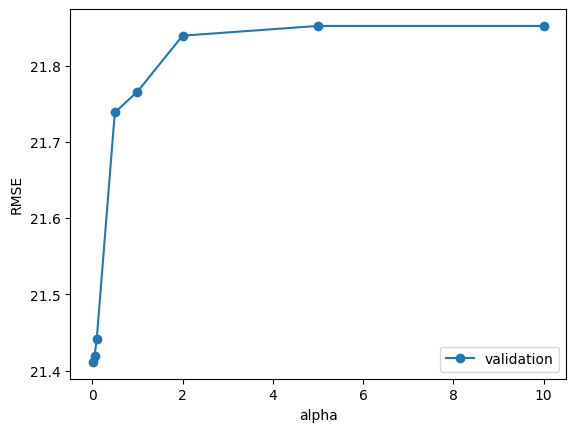

In [39]:
plt.plot(values_alpha, values_rmse, '-o', label='validation')
plt.xlabel('alpha')
plt.ylabel('RMSE')
plt.legend()
plt.show()

In [40]:
model = lm.Lasso(alpha=1)
model.fit(X_train, y_train)

yhat_val = model.predict(X_validation)

In [41]:
#Ensaio sobre os dados de validação

r2_value = mt.r2_score(y_validation, yhat_val)
mse_value = mt.mean_squared_error(y_validation,yhat_val)
rmse_value = np.sqrt(mse_value)
mae_value = mt.mean_absolute_error(y_validation,yhat_val)
mape_value = mt.mean_absolute_percentage_error(y_validation,yhat_val)

print(f"R2 : {r2_value} ")
print(f"MSE : {mse_value} ")
print(f"RMSE : {rmse_value} ")
print(f"MAE : {mae_value} ")
print(f"MAPE : {mape_value} ")

R2 : 0.007883642924698453 
MSE : 473.7470809154487 
RMSE : 21.76573180289256 
MAE : 17.26492176467576 
MAPE : 8.695808367641687 


In [42]:
#Junção dos dados de treinamento com os de validação
model_last = lm.Lasso(alpha=1)
model_last.fit(np.concatenate([X_train, X_validation]), np.concatenate([y_train, y_validation]))

yhat_test = model_last.predict(X_test)

c:\Users\oheit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but Lasso was fitted without feature names
  warnings.warn(


In [43]:
#Ensaio sobre os dados de teste

r2_value = mt.r2_score(y_test, yhat_test)
mse_value = mt.mean_squared_error(y_test,yhat_test)
rmse_value = np.sqrt(mse_value)
mae_value = mt.mean_absolute_error(y_test,yhat_test)
mape_value = mt.mean_absolute_percentage_error(y_test,yhat_test)

print(f"R2 : {r2_value} ")
print(f"MSE : {mse_value} ")
print(f"RMSE : {rmse_value} ")
print(f"MAE : {mae_value} ")
print(f"MAPE : {mape_value} ")

R2 : 0.007813836681452746 
MSE : 483.09641118147954 
RMSE : 21.979454296717186 
MAE : 17.472410054642754 
MAPE : 8.752994861198776 


## 6. Linear Regression Ridge

In [44]:
model = lm.Ridge(alpha=1)
model.fit(X_train, y_train)

yhat_train = model.predict(X_train)

In [45]:
#Ensaio sobre os dados de treinamento

r2_value = mt.r2_score(y_train, yhat_train)
mse_value = mt.mean_squared_error(y_train,yhat_train)
rmse_value = np.sqrt(mse_value)
mae_value = mt.mean_absolute_error(y_train,yhat_train)
mape_value = mt.mean_absolute_percentage_error(y_train,yhat_train)

print(f"R2 : {r2_value} ")
print(f"MSE : {mse_value} ")
print(f"RMSE : {rmse_value} ")
print(f"MAE : {mae_value} ")
print(f"MAPE : {mape_value} ")

R2 : 0.04605770063554282 
MSE : 455.99640059223805 
RMSE : 21.354072225040312 
MAE : 16.998307602320097 
MAPE : 8.653414734181558 


In [46]:
#Busca de hiperparâmetro (alpha) usando os dados de validação
values_alpha = [0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10]
values_rmse = list()

for i in values_alpha:
    model = lm.Ridge(alpha=i)
    model.fit(X_train, y_train)

    yhat_val = model.predict(X_validation)
    mse = mt.mean_squared_error(y_validation, yhat_val)

    values_rmse.append(np.sqrt(mse))

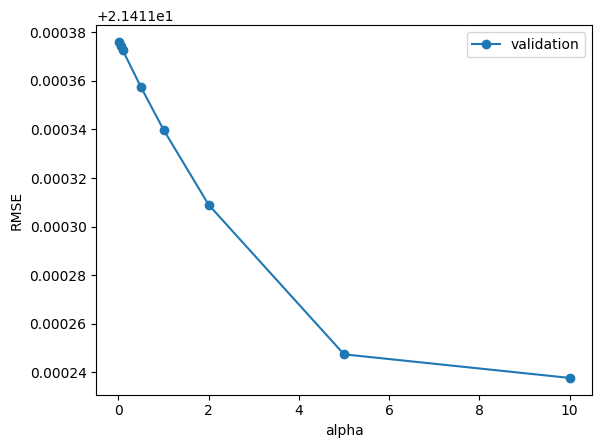

In [47]:
plt.plot(values_alpha, values_rmse, '-o', label='validation')
plt.xlabel('alpha')
plt.ylabel('RMSE')
plt.legend()
plt.show()

In [48]:
model = lm.Ridge(alpha=1)
model.fit(X_train, y_train)

yhat_val = model.predict(X_validation)

In [49]:
#Ensaio sobre os dados de validação

r2_value = mt.r2_score(y_validation, yhat_val)
mse_value = mt.mean_squared_error(y_validation,yhat_val)
rmse_value = np.sqrt(mse_value)
mae_value = mt.mean_absolute_error(y_validation,yhat_val)
mape_value = mt.mean_absolute_percentage_error(y_validation,yhat_val)

print(f"R2 : {r2_value} ")
print(f"MSE : {mse_value} ")
print(f"RMSE : {rmse_value} ")
print(f"MAE : {mae_value} ")
print(f"MAPE : {mape_value} ")

R2 : 0.03992810824954407 
MSE : 458.4454766238971 
RMSE : 21.41133990725235 
MAE : 17.0394715713122 
MAPE : 8.68241248447534 


In [50]:
#Junção dos dados de treinamento com os de validação
model_last = lm.Ridge(alpha=1)
model_last.fit(np.concatenate([X_train, X_validation]), np.concatenate([y_train, y_validation]))

yhat_test = model_last.predict(X_test)

c:\Users\oheit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but Ridge was fitted without feature names
  warnings.warn(


In [51]:
#Ensaio sobre os dados de teste

r2_value = mt.r2_score(y_test, yhat_test)
mse_value = mt.mean_squared_error(y_test,yhat_test)
rmse_value = np.sqrt(mse_value)
mae_value = mt.mean_absolute_error(y_test,yhat_test)
mape_value = mt.mean_absolute_percentage_error(y_test,yhat_test)

print(f"R2 : {r2_value} ")
print(f"MSE : {mse_value} ")
print(f"RMSE : {rmse_value} ")
print(f"MAE : {mae_value} ")
print(f"MAPE : {mape_value} ")

R2 : 0.05116687978503209 
MSE : 461.9877721866712 
RMSE : 21.49390081364179 
MAE : 17.143954082896123 
MAPE : 8.532045909511716 


## 7. Linear Regression Elastic Net

In [52]:
model = lm.ElasticNet(alpha=1, l1_ratio=0.5)
model.fit(X_train, y_train)

yhat_train = model.predict(X_train)

In [53]:
#Ensaio sobre os dados de treinamento

r2_value = mt.r2_score(y_train, yhat_train)
mse_value = mt.mean_squared_error(y_train,yhat_train)
rmse_value = np.sqrt(mse_value)
mae_value = mt.mean_absolute_error(y_train,yhat_train)
mape_value = mt.mean_absolute_percentage_error(y_train,yhat_train)

print(f"R2 : {r2_value} ")
print(f"MSE : {mse_value} ")
print(f"RMSE : {rmse_value} ")
print(f"MAE : {mae_value} ")
print(f"MAPE : {mape_value} ")

R2 : 0.007831741118630053 
MSE : 474.2688893586024 
RMSE : 21.777715430196125 
MAE : 17.299506969671594 
MAPE : 8.732300419042266 


In [54]:
#Busca de hiperparâmetro (alpha) usando os dados de validação
values_alpha = [0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10]
values_rmse = list()

for i in values_alpha:
    model = lm.ElasticNet(alpha=i, l1_ratio=0.5)
    model.fit(X_train, y_train)

    yhat_val = model.predict(X_validation)
    mse = mt.mean_squared_error(y_validation, yhat_val)

    values_rmse.append(np.sqrt(mse))

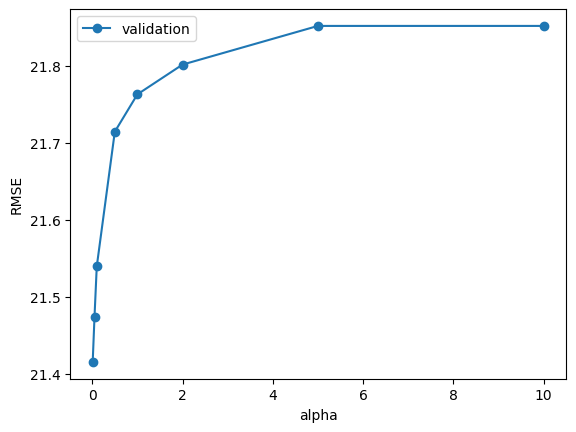

In [55]:
plt.plot(values_alpha, values_rmse, '-o', label='validation')
plt.xlabel('alpha')
plt.ylabel('RMSE')
plt.legend()
plt.show()

In [56]:
model = lm.ElasticNet(alpha=1, l1_ratio=0.5)
model.fit(X_train, y_train)

yhat_val = model.predict(X_validation)

In [57]:
#Ensaio sobre os dados de validação

r2_value = mt.r2_score(y_validation, yhat_val)
mse_value = mt.mean_squared_error(y_validation,yhat_val)
rmse_value = np.sqrt(mse_value)
mae_value = mt.mean_absolute_error(y_validation,yhat_val)
mape_value = mt.mean_absolute_percentage_error(y_validation,yhat_val)

print(f"R2 : {r2_value} ")
print(f"MSE : {mse_value} ")
print(f"RMSE : {rmse_value} ")
print(f"MAE : {mae_value} ")
print(f"MAPE : {mape_value} ")

R2 : 0.00811707101546788 
MSE : 473.6356162915494 
RMSE : 21.76317109916543 
MAE : 17.26290253848956 
MAPE : 8.694035085887595 


In [58]:
#Junção dos dados de treinamento com os de validação
model_last = lm.ElasticNet(alpha=1, l1_ratio=0.5)
model_last.fit(np.concatenate([X_train, X_validation]), np.concatenate([y_train, y_validation]))

yhat_test = model_last.predict(X_test)

c:\Users\oheit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but ElasticNet was fitted without feature names
  warnings.warn(


In [59]:
#Ensaio sobre os dados de teste

r2_value = mt.r2_score(y_test, yhat_test)
mse_value = mt.mean_squared_error(y_test,yhat_test)
rmse_value = np.sqrt(mse_value)
mae_value = mt.mean_absolute_error(y_test,yhat_test)
mape_value = mt.mean_absolute_percentage_error(y_test,yhat_test)

print(f"R2 : {r2_value} ")
print(f"MSE : {mse_value} ")
print(f"RMSE : {rmse_value} ")
print(f"MAE : {mae_value} ")
print(f"MAPE : {mape_value} ")

R2 : 0.00789698095329816 
MSE : 483.0559281543786 
RMSE : 21.97853334857398 
MAE : 17.47162951427036 
MAPE : 8.746262576424071 


## 8. Polinomial Regression Lasso

In [60]:
poly = pp.PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_validation_poly = poly.transform(X_validation)
X_test_poly = poly.transform(X_test)

model = lm.Lasso(alpha=1)
model.fit(X_train_poly, y_train)

yhat_train = model.predict(X_train_poly)

In [61]:
#Ensaio sobre os dados de treinamento

r2_value = mt.r2_score(y_train, yhat_train)
mse_value = mt.mean_squared_error(y_train,yhat_train)
rmse_value = np.sqrt(mse_value)
mae_value = mt.mean_absolute_error(y_train,yhat_train)
mape_value = mt.mean_absolute_percentage_error(y_train,yhat_train)

print(f"R2 : {r2_value} ")
print(f"MSE : {mse_value} ")
print(f"RMSE : {rmse_value} ")
print(f"MAE : {mae_value} ")
print(f"MAPE : {mape_value} ")

R2 : 0.009149935251170582 
MSE : 473.6387760067563 
RMSE : 21.763243692215468 
MAE : 17.285449661261286 
MAPE : 8.699700898061742 


In [62]:
#Busca de hiperparâmetro (alpha) usando os dados de validação
values_alpha = [0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10]
values_rmse = list()

for i in values_alpha:
    model = lm.Lasso(alpha=i)
    model.fit(X_train_poly, y_train)

    yhat_val = model.predict(X_validation_poly)
    mse = mt.mean_squared_error(y_validation, yhat_val)

    values_rmse.append(np.sqrt(mse))

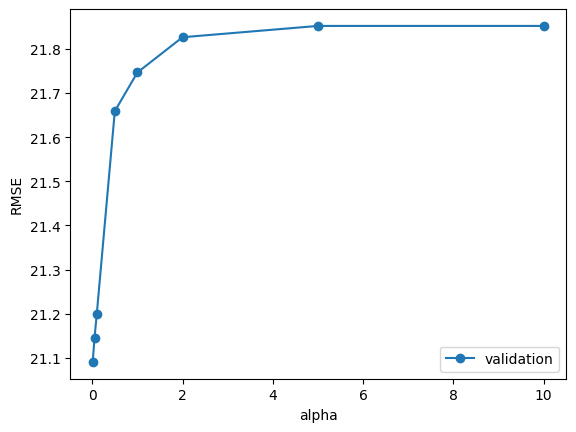

In [63]:
plt.plot(values_alpha, values_rmse, '-o', label='validation')
plt.xlabel('alpha')
plt.ylabel('RMSE')
plt.legend()
plt.show()

In [64]:
model = lm.Lasso(alpha=1)
model.fit(X_train_poly, y_train)

yhat_val = model.predict(X_validation_poly)

In [65]:
#Ensaio sobre os dados de validação

r2_value = mt.r2_score(y_validation, yhat_val)
mse_value = mt.mean_squared_error(y_validation,yhat_val)
rmse_value = np.sqrt(mse_value)
mae_value = mt.mean_absolute_error(y_validation,yhat_val)
mape_value = mt.mean_absolute_percentage_error(y_validation,yhat_val)

print(f"R2 : {r2_value} ")
print(f"MSE : {mse_value} ")
print(f"RMSE : {rmse_value} ")
print(f"MAE : {mae_value} ")
print(f"MAPE : {mape_value} ")

R2 : 0.009631007774810185 
MSE : 472.91269390919564 
RMSE : 21.746555909136408 
MAE : 17.238378728440562 
MAPE : 8.681846557814454 


In [66]:
#Junção dos dados de treinamento com os de validação
model_last = lm.Lasso(alpha=1)
model_last.fit(np.concatenate([X_train_poly, X_validation_poly]), np.concatenate([y_train, y_validation]))

yhat_test = model_last.predict(X_test_poly)

In [67]:
#Ensaio sobre os dados de teste

r2_value = mt.r2_score(y_test, yhat_test)
mse_value = mt.mean_squared_error(y_test,yhat_test)
rmse_value = np.sqrt(mse_value)
mae_value = mt.mean_absolute_error(y_test,yhat_test)
mape_value = mt.mean_absolute_percentage_error(y_test,yhat_test)

print(f"R2 : {r2_value} ")
print(f"MSE : {mse_value} ")
print(f"RMSE : {rmse_value} ")
print(f"MAE : {mae_value} ")
print(f"MAPE : {mape_value} ")

R2 : 0.008803004933415903 
MSE : 482.6147841942822 
RMSE : 21.96849526468033 
MAE : 17.456171144521186 
MAPE : 8.75564456604869 


## 9. Polinomial Regression Ridge

In [68]:
poly = pp.PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_validation_poly = poly.transform(X_validation)
X_test_poly = poly.transform(X_test)

model = lm.Ridge(alpha=1)
model.fit(X_train_poly, y_train)

yhat_train = model.predict(X_train_poly)

In [69]:
#Ensaio sobre os dados de treinamento

r2_value = mt.r2_score(y_train, yhat_train)
mse_value = mt.mean_squared_error(y_train,yhat_train)
rmse_value = np.sqrt(mse_value)
mae_value = mt.mean_absolute_error(y_train,yhat_train)
mape_value = mt.mean_absolute_percentage_error(y_train,yhat_train)

print(f"R2 : {r2_value} ")
print(f"MSE : {mse_value} ")
print(f"RMSE : {rmse_value} ")
print(f"MAE : {mae_value} ")
print(f"MAPE : {mape_value} ")

R2 : 0.09317140761274367 
MSE : 433.47545690992723 
RMSE : 20.82007341269303 
MAE : 16.47197183768649 
MAPE : 8.372689165744578 


In [70]:
#Busca de hiperparâmetro (alpha) usando os dados de validação
values_alpha = [0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10]
values_rmse = list()

for i in values_alpha:
    model = lm.Ridge(alpha=i)
    model.fit(X_train_poly, y_train)

    yhat_val = model.predict(X_validation_poly)
    mse = mt.mean_squared_error(y_validation, yhat_val)

    values_rmse.append(np.sqrt(mse))

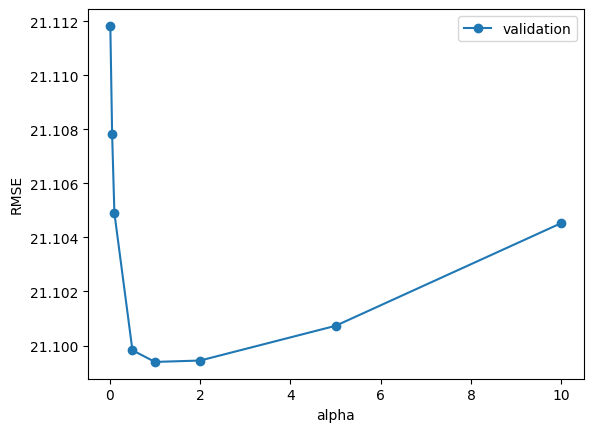

In [71]:
plt.plot(values_alpha, values_rmse, '-o', label='validation')
plt.xlabel('alpha')
plt.ylabel('RMSE')
plt.legend()
plt.show()

In [72]:
model = lm.Ridge(alpha=1)
model.fit(X_train_poly, y_train)

yhat_val = model.predict(X_validation_poly)

In [73]:
#Ensaio sobre os dados de validação

r2_value = mt.r2_score(y_validation, yhat_val)
mse_value = mt.mean_squared_error(y_validation,yhat_val)
rmse_value = np.sqrt(mse_value)
mae_value = mt.mean_absolute_error(y_validation,yhat_val)
mape_value = mt.mean_absolute_percentage_error(y_validation,yhat_val)

print(f"R2 : {r2_value} ")
print(f"MSE : {mse_value} ")
print(f"RMSE : {rmse_value} ")
print(f"MAE : {mae_value} ")
print(f"MAPE : {mape_value} ")

R2 : 0.0676992996679171 
MSE : 445.184410243757 
RMSE : 21.09939359895817 
MAE : 16.73874061169058 
MAPE : 8.568992470935276 


In [74]:
#Junção dos dados de treinamento com os de validação
model_last = lm.Ridge(alpha=1)
model_last.fit(np.concatenate([X_train_poly, X_validation_poly]), np.concatenate([y_train, y_validation]))

yhat_test = model_last.predict(X_test_poly)

In [75]:
#Ensaio sobre os dados de teste

r2_value = mt.r2_score(y_test, yhat_test)
mse_value = mt.mean_squared_error(y_test,yhat_test)
rmse_value = np.sqrt(mse_value)
mae_value = mt.mean_absolute_error(y_test,yhat_test)
mape_value = mt.mean_absolute_percentage_error(y_test,yhat_test)

print(f"R2 : {r2_value} ")
print(f"MSE : {mse_value} ")
print(f"RMSE : {rmse_value} ")
print(f"MAE : {mae_value} ")
print(f"MAPE : {mape_value} ")

R2 : 0.09023105908000806 
MSE : 442.9673851657187 
RMSE : 21.046790376818 
MAE : 16.742213878468082 
MAPE : 8.308500709997759 


## 10. Polinomial Regression Elastic Net

In [76]:
poly = pp.PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_validation_poly = poly.transform(X_validation)
X_test_poly = poly.transform(X_test)

model = lm.ElasticNet(alpha=1, l1_ratio=0.5)
model.fit(X_train_poly, y_train)

yhat_train = model.predict(X_train_poly)

In [77]:
#Ensaio sobre os dados de treinamento

r2_value = mt.r2_score(y_train, yhat_train)
mse_value = mt.mean_squared_error(y_train,yhat_train)
rmse_value = np.sqrt(mse_value)
mae_value = mt.mean_absolute_error(y_train,yhat_train)
mape_value = mt.mean_absolute_percentage_error(y_train,yhat_train)

print(f"R2 : {r2_value} ")
print(f"MSE : {mse_value} ")
print(f"RMSE : {rmse_value} ")
print(f"MAE : {mae_value} ")
print(f"MAPE : {mape_value} ")

R2 : 0.012832763427018778 
MSE : 471.8783378824533 
RMSE : 21.722760825513255 
MAE : 17.244236014680347 
MAPE : 8.678785850035073 


In [78]:
#Busca de hiperparâmetro (alpha) usando os dados de validação
values_alpha = [0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10]
values_rmse = list()

for i in values_alpha:
    model = lm.ElasticNet(alpha=i, l1_ratio=0.5)
    model.fit(X_train_poly, y_train)

    yhat_val = model.predict(X_validation_poly)
    mse = mt.mean_squared_error(y_validation, yhat_val)

    values_rmse.append(np.sqrt(mse))

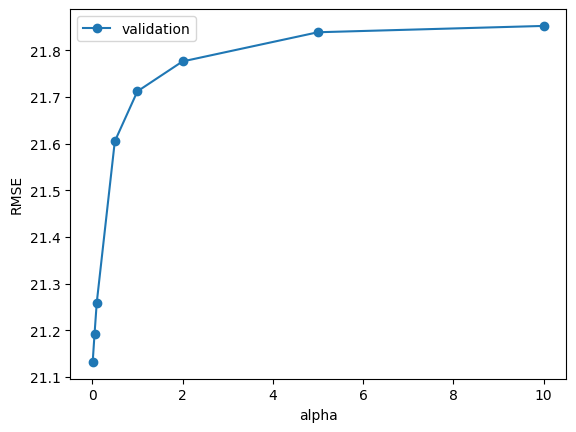

In [79]:
plt.plot(values_alpha, values_rmse, '-o', label='validation')
plt.xlabel('alpha')
plt.ylabel('RMSE')
plt.legend()
plt.show()

In [80]:
model = lm.ElasticNet(alpha=1, l1_ratio=0.5)
model.fit(X_train_poly, y_train)

yhat_val = model.predict(X_validation_poly)

In [81]:
#Ensaio sobre os dados de validação

r2_value = mt.r2_score(y_validation, yhat_val)
mse_value = mt.mean_squared_error(y_validation,yhat_val)
rmse_value = np.sqrt(mse_value)
mae_value = mt.mean_absolute_error(y_validation,yhat_val)
mape_value = mt.mean_absolute_percentage_error(y_validation,yhat_val)

print(f"R2 : {r2_value} ")
print(f"MSE : {mse_value} ")
print(f"RMSE : {rmse_value} ")
print(f"MAE : {mae_value} ")
print(f"MAPE : {mape_value} ")

R2 : 0.012781775822342856 
MSE : 471.4081655799173 
RMSE : 21.711936016392396 
MAE : 17.19996619878308 
MAPE : 8.675108462242978 


In [82]:
#Junção dos dados de treinamento com os de validação
model_last = lm.ElasticNet(alpha=1, l1_ratio=0.5)
model_last.fit(np.concatenate([X_train_poly, X_validation_poly]), np.concatenate([y_train, y_validation]))

yhat_test = model_last.predict(X_test_poly)

In [83]:
#Ensaio sobre os dados de teste

r2_value = mt.r2_score(y_test, yhat_test)
mse_value = mt.mean_squared_error(y_test,yhat_test)
rmse_value = np.sqrt(mse_value)
mae_value = mt.mean_absolute_error(y_test,yhat_test)
mape_value = mt.mean_absolute_percentage_error(y_test,yhat_test)

print(f"R2 : {r2_value} ")
print(f"MSE : {mse_value} ")
print(f"RMSE : {rmse_value} ")
print(f"MAE : {mae_value} ")
print(f"MAPE : {mape_value} ")

R2 : 0.011017491167491067 
MSE : 481.5365486858224 
RMSE : 21.94394104726456 
MAE : 17.426959777435652 
MAPE : 8.753618159681038 


## Tabela resumo - todos os algoritmos (dados de teste)

In [88]:
#Tabela resumo consolidada - dados de teste

resumo_teste = pd.DataFrame({
    'Algoritmo': ['Decision Tree Regreession','Regression Polinomial', 'Linear Regression', 'Random Forest Regressor',
                  'Linear Regression Lasso', 'Linear Regression Ridge', 'Linear Regression Elastic Net',
                  'Polinomial Regression Lasso', 'Polinomial Regression Ridge', 'Polinomial Regression Elastic Net'],
    'R2': [0.0650, 0.0909, 0.0512, 0.4040, 0.0078, 0.0512, 0.0079,
           0.0088, 0.0902, 0.0110],
    'MSE': [455.22, 442.64, 461.99, 290.20, 483.10, 461.99, 483.06,
            482.62, 442.97, 481.54],
    'RMSE': [21.336, 21.039, 21.494, 17.035, 21.979, 21.494, 21.979,
             21.968, 21.047, 21.944],
    'MAE': [17.033, 16.736, 17.144, 12.227, 17.472, 17.144, 17.472,
            17.456, 16.742, 17.427],
    'MAPE': [8.129, 8.276, 8.531, 6.338, 8.753, 8.532, 8.746,
             8.756, 8.309, 8.754]
})
resumo_teste


,Algoritmo,R2,MSE,RMSE,MAE,MAPE
0,Decision Tree Regreession,0.0650,455.22,21.336,17.033,8.129
1,Regression Polinomial,0.0909,442.64,21.039,16.736,8.276
2,Linear Regression,0.0512,461.99,21.494,17.144,8.531
3,Random Forest Regressor,0.4040,290.20,17.035,12.227,6.338
4,Linear Regression Lasso,0.0078,483.10,21.979,17.472,8.753
5,Linear Regression Ridge,0.0512,461.99,21.494,17.144,8.532
6,Linear Regression Elastic Net,0.0079,483.06,21.979,17.472,8.746
7,Polinomial Regression Lasso,0.0088,482.62,21.968,17.456,8.756
8,Polinomial Regression Ridge,0.0902,442.97,21.047,16.742,8.309
9,Polinomial Regression Elastic Net,0.0110,481.54,21.944,17.427,8.754
